<a href="https://colab.research.google.com/github/ahmedosman2a/Basel-AML-Index-Analysis/blob/main/Post_2017_SDL_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded 1047 articles.
Visualization 1: Word Cloud saved as 'viz_1_word_cloud.png'
Visualization 2: Methodology Bar Chart saved as 'viz_2_methodology_breakdown.png'
Visualization 3: Theory Score Histogram saved as 'viz_3_theory_score_histogram.png'
Visualization 4: Comparative Pie Chart saved as 'viz_4_comparative_pie.png'

--- ALL VISUALIZATIONS GENERATED ---


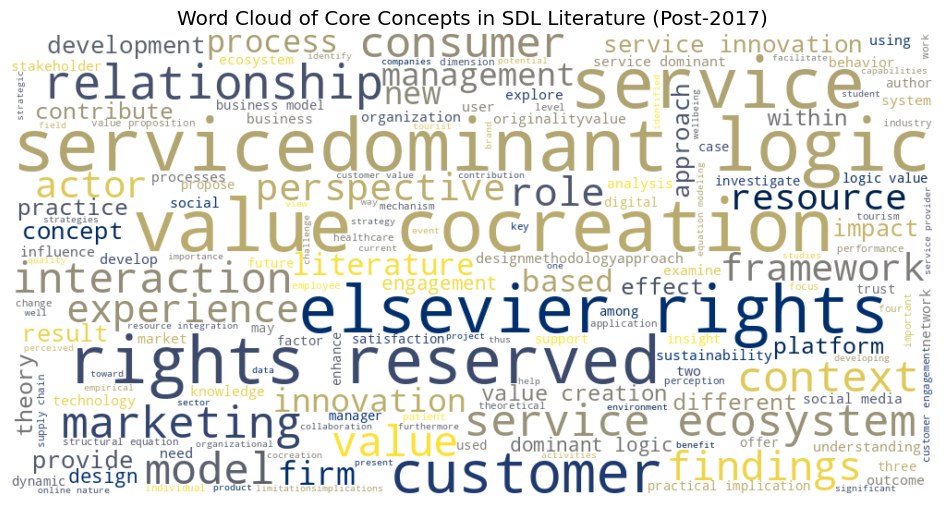

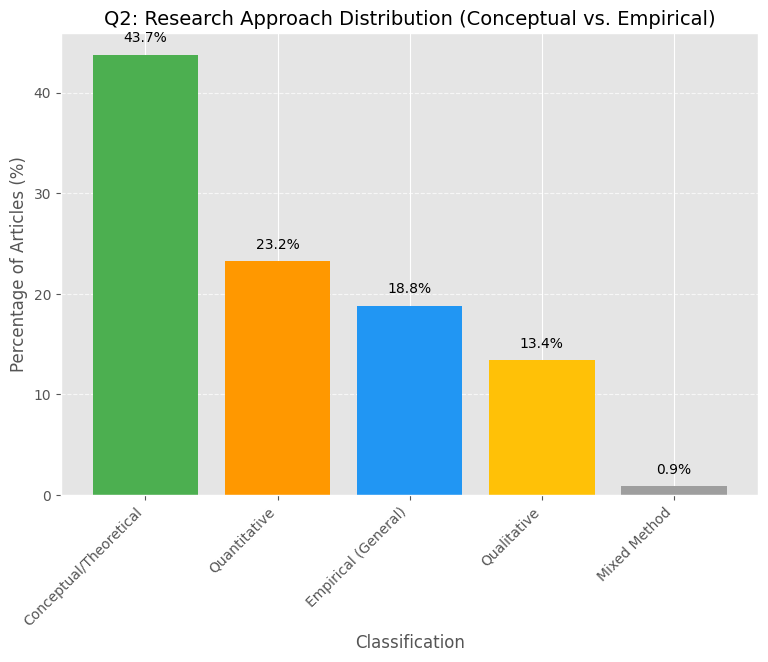

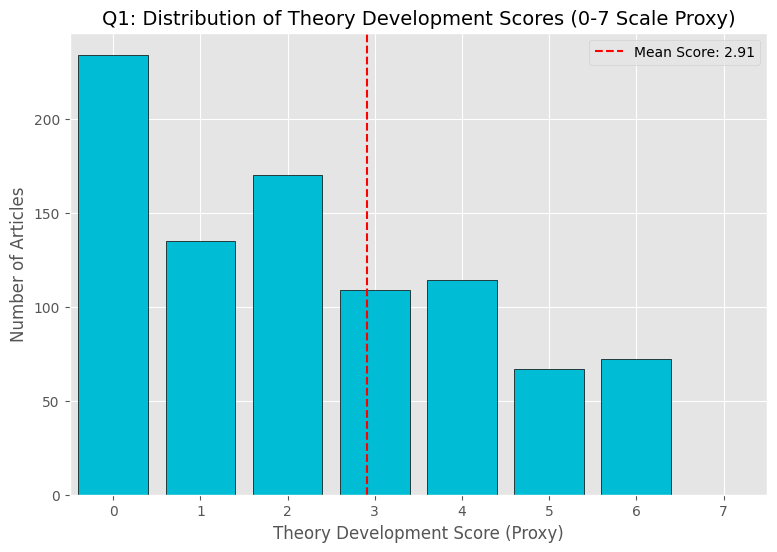

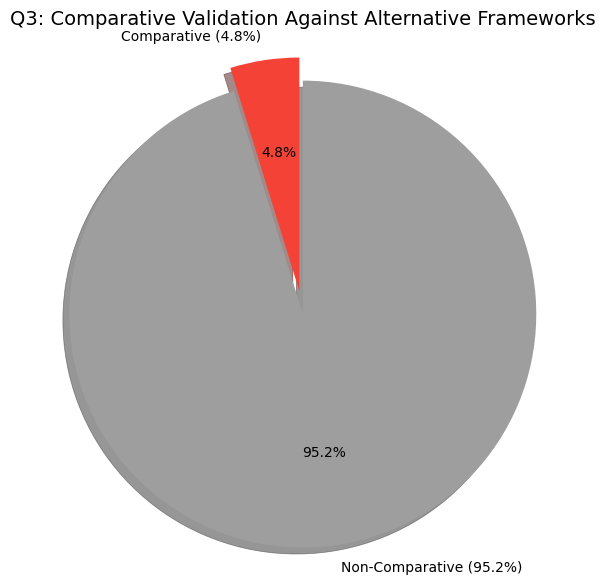

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from nltk.corpus import stopwords

# --- CONFIGURATION (UPDATE THESE) ---
FILE_NAME = '/content/scopus_export_Nov 16-2025_625827ff-9527-4e7a-8a07-40d75143553d.csv'
TEXT_COLUMN = 'Abstract'
KEYWORDS_COLUMN = 'Author Keywords'
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['article', 'study', 'research', 'paper', 'finding', 'aim', 'method', 'show', 'use', 'vargo', 'lusch', 'sdl', 'service-dominant'])

# --- ADVANCED KEYWORD DICTIONARIES ---

THEORY_DEVELOPMENT_WEIGHTS = {
    'high_score': ['proposition', 'testable hypothesis', 'causal mechanism', 'theoretical contribution', 'conceptual framework'],
    'mid_score': ['develop a model', 'model', 'framework', 'typology', 'theoretical lens', 'extending theory'],
    'low_score': ['axiom', 'perspective', 'conceptualization', 'implications']
}

EMPIRICAL_MARKERS = {
    'quantitative': ['regression', 'anova', 'sem', 'structural equation', 'statistical', 'survey data', 'scale development', 'measurement', 'econometric'],
    'qualitative': ['grounded theory', 'thematic analysis', 'narrative', 'interpretive', 'case study', 'interview', 'ethnography', 'coding'],
    'mixed_method': ['mixed method', 'triangulation', 'integrative analysis']
}

COMPARATIVE_MARKERS = ['comparative', 'comparison', 'versus', 'outperform', 'alternative framework', 'test against', 'cross-country', 'cross-cultural', 'multi-context']

# --- DATA LOADING AND CLEANING ---

try:
    df = pd.read_csv(FILE_NAME)
    df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna('')
    df[KEYWORDS_COLUMN] = df[KEYWORDS_COLUMN].fillna('')
    df['Text_Cleaned'] = df[TEXT_COLUMN].str.lower()
    df['Text_For_WordCloud'] = df['Text_Cleaned'] + ' ' + df[KEYWORDS_COLUMN].str.lower()
    print(f"Loaded {len(df)} articles.")
except FileNotFoundError:
    print(f"Error: File '{FILE_NAME}' not found.")
    # Removed exit() to allow the notebook to continue, though df would still be undefined

# --- CORE FUNCTIONS (From previous response) ---

def classify_methodology(text, empirical_markers):
    quant_found = any(re.search(r'\b' + re.escape(k) + r'\b', text) for k in empirical_markers['quantitative'])
    qual_found = any(re.search(r'\b' + re.escape(k) + r'\b', text) for k in empirical_markers['qualitative'])
    mixed_found = any(re.search(r'\b' + re.escape(k) + r'\b', text) for k in empirical_markers['mixed_method'])
    general_empirical = re.search(r'\b(data analysis|evidence|results|finding)\b', text)

    if mixed_found or (quant_found and qual_found):
        return 'Mixed Method'
    elif quant_found:
        return 'Quantitative'
    elif qual_found:
        return 'Qualitative'
    elif general_empirical:
        return 'Empirical (General)'
    else:
        return 'Conceptual/Theoretical'

def score_theory_development(text, weights):
    score = 0
    for keyword in weights['high_score']:
        score += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text)) * 3
    for keyword in weights['mid_score']:
        score += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text)) * 2
    for keyword in weights['low_score']:
        score += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text)) * 1
    return min(score, 7)

def check_comparison(text, markers):
    return any(re.search(r'\b' + re.escape(k) + r'\b', text) for k in markers)

def preprocess_for_wordcloud(text):
    """Clean text by removing punctuation and stop words."""
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    words = text.split()
    meaningful_words = [word for word in words if word not in STOP_WORDS and len(word) > 2]
    return ' '.join(meaningful_words)

# --- APPLY ANALYSIS ---

df['Methodology_Class'] = df['Text_Cleaned'].apply(lambda x: classify_methodology(x, EMPIRICAL_MARKERS))
df['Theory_Development_Score'] = df['Text_Cleaned'].apply(lambda x: score_theory_development(x, THEORY_DEVELOPMENT_WEIGHTS))
df['Has_Comparative_Test'] = df['Text_Cleaned'].apply(lambda x: check_comparison(x, COMPARATIVE_MARKERS))

# --- VISUALIZATION SECTION ---

plt.style.use('ggplot')

## 1. Word Cloud (General Overview)
all_text = ' '.join(df['Text_For_WordCloud'].apply(preprocess_for_wordcloud))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='cividis',
    min_font_size=10
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Core Concepts in SDL Literature (Post-2017)")
plt.savefig('viz_1_word_cloud.png', bbox_inches='tight')
print("Visualization 1: Word Cloud saved as 'viz_1_word_cloud.png'")
#

## 2. Methodology Breakdown (Q2) - Bar Chart
method_counts = df['Methodology_Class'].value_counts(normalize=True).sort_values(ascending=False) * 100
colors = ['#4CAF50', '#FF9800', '#2196F3', '#FFC107', '#9E9E9E']

plt.figure(figsize=(9, 6))
bars = plt.bar(method_counts.index, method_counts.values, color=colors[:len(method_counts)])
plt.title('Q2: Research Approach Distribution (Conceptual vs. Empirical)', fontsize=14)
plt.ylabel('Percentage of Articles (%)', fontsize=12)
plt.xlabel('Classification', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add percentages on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=10)

plt.savefig('viz_2_methodology_breakdown.png', bbox_inches='tight')
print("Visualization 2: Methodology Bar Chart saved as 'viz_2_methodology_breakdown.png'")

## 3. Theory Development Score Distribution (Q1) - Histogram
plt.figure(figsize=(9, 6))
# Create bins from 0 to 7
bins = np.arange(0, 8, 1) - 0.5
plt.hist(df['Theory_Development_Score'], bins=bins, rwidth=0.8, color='#00BCD4', edgecolor='black', align='mid')

plt.title('Q1: Distribution of Theory Development Scores (0-7 Scale Proxy)', fontsize=14)
plt.xlabel('Theory Development Score (Proxy)', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(np.arange(0, 8, 1))
plt.xlim(-0.5, 7.5)
plt.axvline(x=df['Theory_Development_Score'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean Score: {df["Theory_Development_Score"].mean():.2f}')
plt.legend()
plt.savefig('viz_3_theory_score_histogram.png', bbox_inches='tight')
print("Visualization 3: Theory Score Histogram saved as 'viz_3_theory_score_histogram.png'")

## 4. Comparative Studies (Q3) - Pie Chart
comp_data = df['Has_Comparative_Test'].value_counts()
N = len(df) # Get total number of articles before using comp_data for labels
labels = [f'Comparative ({comp_data.get(True, 0)/N:.1%})', f'Non-Comparative ({comp_data.get(False, 0)/N:.1%})']
sizes = [comp_data.get(True, 0), comp_data.get(False, 0)] # Use .get with default 0 in case one category is missing
explode = (0.1, 0)  # Explode the 'Comparative' slice

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, colors=['#F44336', '#9E9E9E'])
plt.title('Q3: Comparative Validation Against Alternative Frameworks', fontsize=14)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.savefig('viz_4_comparative_pie.png', bbox_inches='tight')
print("Visualization 4: Comparative Pie Chart saved as 'viz_4_comparative_pie.png'")

print("\n--- ALL VISUALIZATIONS GENERATED ---")